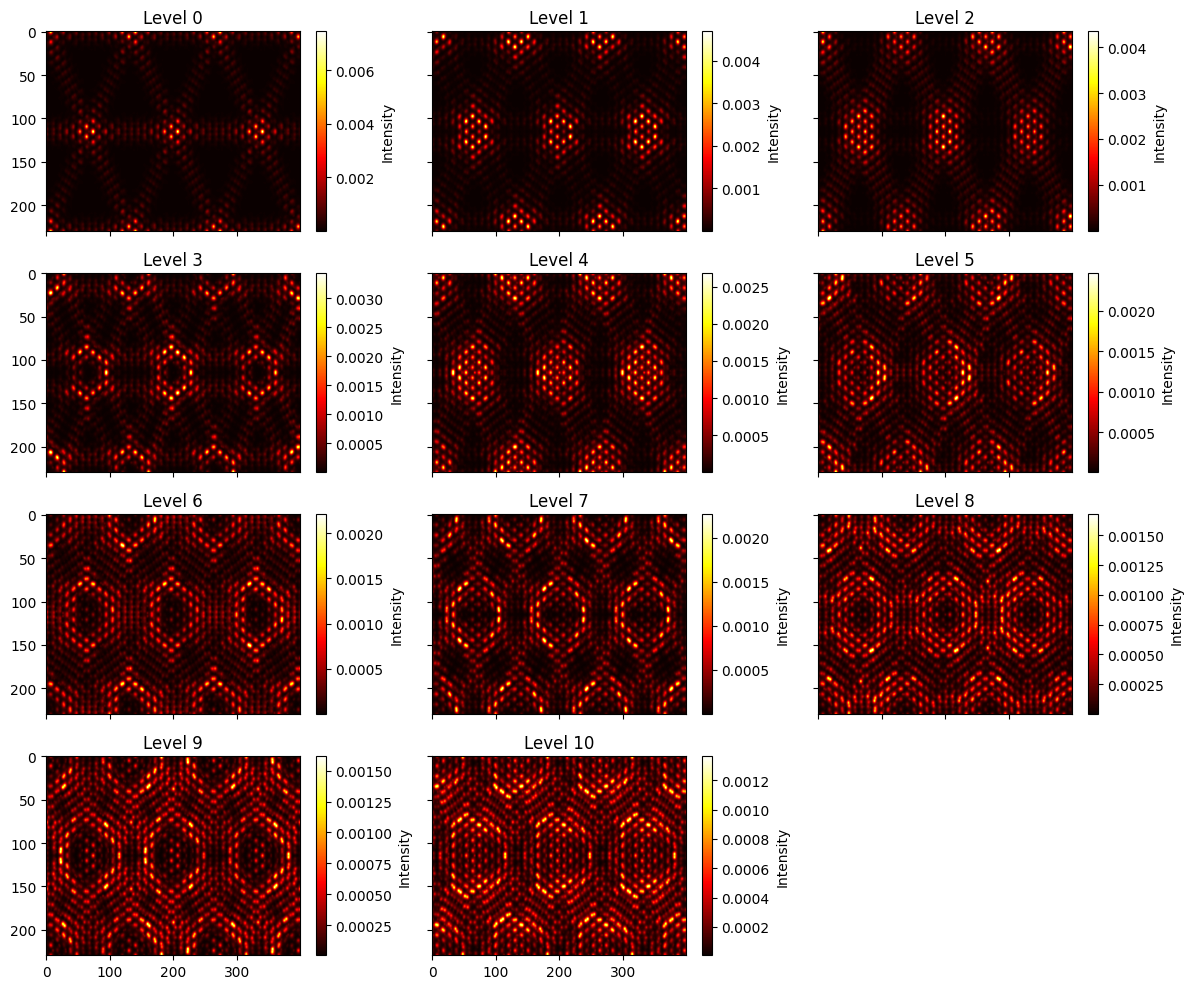

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Define number of rows and columns for subplots
rows, cols = 4, 3  # 4x3 grid
num_files = 11  # Total number of text files
data_array = []

# Create the figure and axes
fig, axes = plt.subplots(rows, cols, figsize=(12, 10), sharex=True, sharey=True)

# Flatten the axes array to make it easier to index
axes = axes.flatten()

for i in range(num_files):
    # Load the text file into a numpy array
    data_array.append(np.loadtxt(f"Local_density_of_states_near_band_edge/local_density_of_states_for_level_{i}.txt", delimiter=","))
    
    # Display the heatmap on the correct subplot
    im = axes[i].imshow(data_array[i], cmap="hot", aspect="auto")  

    # Add a colorbar for each subplot
    fig.colorbar(im, ax=axes[i], label="Intensity")
    axes[i].set_title(f"Level {i}")

# Hide any unused subplots (in case we have extra spaces in 4x3 grid)
for i in range(num_files, rows * cols):
    fig.delaxes(axes[i])

plt.tight_layout()      # Adjust layout to prevent overlapping
plt.savefig('Heatmaps.png')
plt.show()


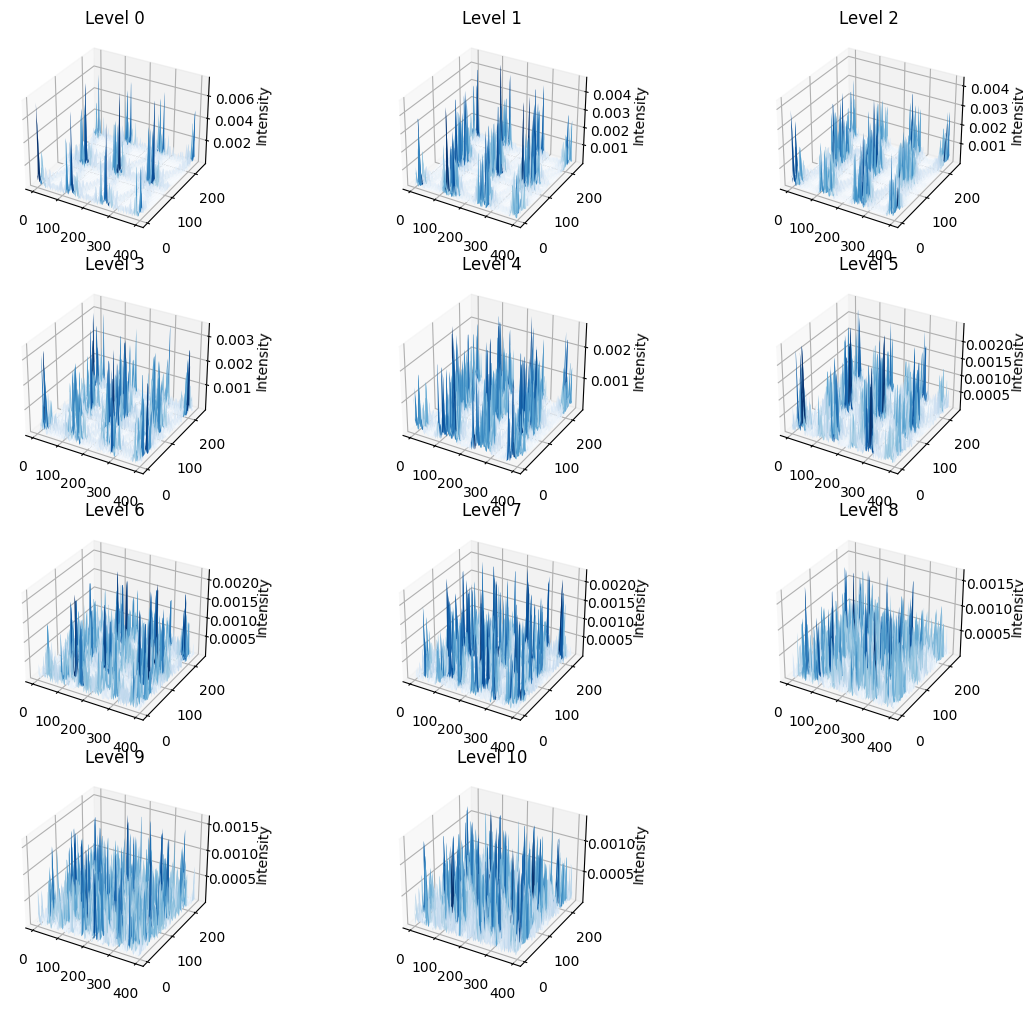

In [2]:
from mpl_toolkits.mplot3d import Axes3D


# Create the figure and axes
fig, axes = plt.subplots(rows, cols, figsize=(12, 10), subplot_kw={'projection': '3d'})
axes = axes.flatten()

for i, data in enumerate(data_array):

    # Get x and y grid based on data shape
    x = np.arange(data.shape[1])
    y = np.arange(data.shape[0])
    X, Y = np.meshgrid(x, y)

    # Generate surface plot
    axes[i].plot_surface(X, Y, data, cmap="Blues", edgecolor="none", rcount=50, ccount=50)

    # Set labels and titles
    axes[i].set_title(f"Level {i}")
    axes[i].set_zlabel("Intensity")

# Hide any unused subplots
for i in range(num_files, rows * cols):
    fig.delaxes(axes[i])

plt.tight_layout()  # Adjust layout before saving
plt.savefig("surface_plots.png", dpi=300)  # Save the figure
plt.show()


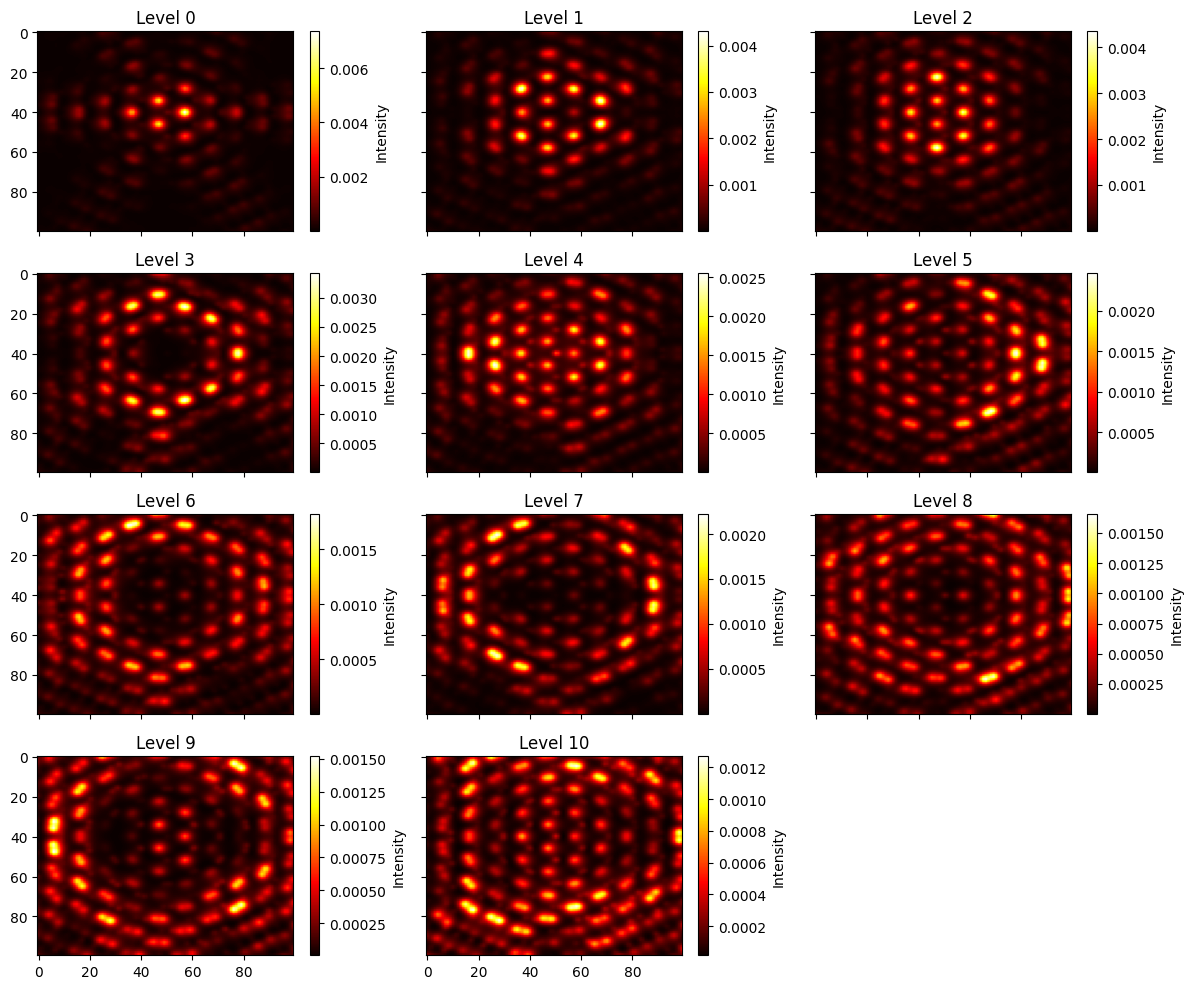

In [ ]:
#take one feature, then look how it changes over the different energy levels.

# Create the figure and axes
fig, axes = plt.subplots(rows, cols, figsize=(12, 10), sharex=True, sharey=True)
axes = axes.flatten()

feature_arr = []

for i, data in enumerate(data_array):

    # Get x and y grid based on data shape
    x = np.arange(150,250)
    y = np.arange(75, 175)
    X, Y = np.meshgrid(x, y)
    feature_data = data[75:175, 150:250]
    feature_arr.append(feature_data)
    
    # Display the heatmap on the correct subplot
    im = axes[i].imshow(feature_data, cmap="hot", aspect="auto")  
    fig.colorbar(im, ax=axes[i], label="Intensity")
    axes[i].set_title(f"Level {i}")

# Hide any unused subplots (in case we have extra spaces in 4x3 grid)
for i in range(num_files, rows * cols):
    fig.delaxes(axes[i])

plt.tight_layout()      # Adjust layout to prevent overlapping
plt.show()


Text(0, 0.5, 'Average intensity')

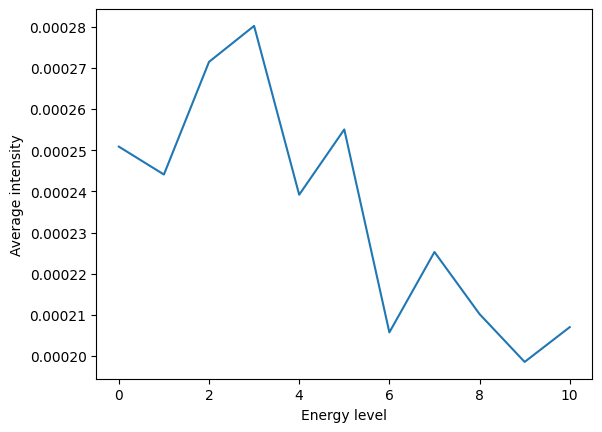

In [20]:
#I'll plot the average intensity in these regions over different energy levels

mvals = []
Elevel_vals = []
for i, data in enumerate(feature_arr):
    mvals.append(np.mean(data))
    Elevel_vals.append(i)



plt.plot(Elevel_vals, mvals)
plt.xlabel('Energy level')
plt.ylabel('Average intensity')


In [ ]:
#Let's double check the images are normalized.

#I'll plot the average intensity in these regions over different energy levels

mvals = []
Elevel_vals = []
for i, data in enumerate(data_array):
    mvals.append(np.mean(data))
    Elevel_vals.append(i)


print(mvals)
#Good I've confirmed they are normalized

[0.0001935714239130435, 0.0001935753695652174, 0.0001935756304347826, 0.00019357621739130433, 0.00019357525, 0.00019357502173913046, 0.00019357586956521741, 0.00019357609782608698, 0.00019357634782608693, 0.00019357326086956523, 0.00019357561956521738]


The first idea that comes to mind is that the density of states (DOS) is spreaing out at higher enrgy levels. Ask nils lol